In [1]:
# Project setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.options.display.float_format = '{:,.0f}'.format # gets rid of scientific notation for some stats
df = pd.read_csv("Beatles.csv")

# Introduction - The Beatles Discography Analysis
The Beatles were a rock band who dominated the 1960s, commercially and culturally. Starting as teenagers playing skiffle music in Liverpool, they evolved into something far more ambitious, incorporating psychadelia, classical arrangements, Indian ragas, and pioneering studio techniques that set them apart from many of their contemporaries. 

This reputation wasn't always set in stone, however. Their early catalog was generally more oriented towards concise pop and rock-and-roll songwriting, while their later work incorporated increasingly diverse styles and studio techniques. The question this analysis attempts to answer: was there a real, measurable shift in the reception of Beatles songs after *Rubber Soul* (1965), often identified to be the turning point in their artistic development?

The dataset used here contains every canonical Beatles song, and was compiled by me from a base Kaggle dataset (sourced in README), with additional columns added from RateYourMusic, AlbumOfTheYear, and Spotify. Columns fall into two broad categories: identification (song and release details), and reception (critical rankings and listener ratings). Several derived variables were also created for analysis, including a composite average rating and a pre/post-*Rubber Soul* classification. 

Column explanations:
| Column | Description |
|--------|-------------|
| id | Song id |
| Side | Album Side |
| Position | Album Position |
| Title | Song Title |
| Date | Date Released |
| Album | Album Title |
| Duration | Song Duration (s) |
| Songwriter | Chief Songwriter(s) |
| LeadVocal | Lead Vocalist(s) |
| Single | Single Side |
| UCM_T50 | UCM Top 50 Ranking |
| RS_T100 | Rolling Stones Top 100 Ranking |
| NME_Rank | NME Ranking |
| USA_Today_rank | USA Today Ranking |
| RYM | RateYourMusic Rating |
| AOTY | AlbumOfTheYear Rating |
| Spotify | Spotify Streams |

Extra notes:
- Release dates are based on the song's earliest official release, rather than its eventual album appearance. This is to allow the analysis to measure whne each song first entered the public catalog.
- Album is 'Single' for singles.
- Songwriter is a bit of a murky datapoint. I took from an exhaustive research project into every song's chief songwriter (as all are credited under Lennon-McCartney, and sometimes Harrison/Starr), though some are bound to be a bit less accurate than others. See README for more details.
- Single is 0 for non-singles, 1 for A-sides, 2 for B-sides.
- RYM data is from 2019, though overall trends should not have changed very much.
- On avg_rating, I simply scaled the RYM data up to 0-100, and took the average between it and AOTY ratings. 
- For full dataset sources and modifications, see the README.

# Setup

In [2]:
# Adjust scales
df['RYM_scaled'] = df['RYM'] * 20  # Scales RYM to 0-100

# Create avg_rating column
df['avg_rating'] = (df['RYM_scaled'] + df['AOTY']) / 2
df['avg_rating'] = pd.to_numeric(df['avg_rating'], errors='coerce')

# Ensure 'Date' column is in datetime format (stuff gets messed up otherwise)
df['Date'] = pd.to_datetime(df['Date'])

# Define Rubber Soul split
rubber_soul_date = pd.to_datetime('1965-12-03')
pre_rs = df[df['Date'] < rubber_soul_date]
post_rs = df[df['Date'] >= rubber_soul_date]

# Define custom album order since I can't do it by date
album_order = ['Single', 'Please Please Me', 'With the Beatles', "A Hard Day's Night", 
               'Beatles for Sale', 'Help!', 'Rubber Soul', 'Revolver', 
               "Sgt. Pepper's Lonely Hearts Club Band", 'Magical Mystery Tour', 
               'The Beatles', 'Yellow Submarine', 'Abbey Road', 'Let It Be']

# Loading
## 1. Dataset Overview

In [3]:
# Dimensions, variable types, and a look at the first 5 rows
print(df.shape)
print(df.dtypes)
df.head()

(206, 19)
id                         int64
Side                         str
Position                 float64
Title                        str
Date              datetime64[us]
Album                        str
Duration                   int64
Songwriter                   str
LeadVocal                    str
Single                     int64
UCM_T50                  float64
RS_T100                  float64
NME_Rank                 float64
USA_Today_rank           float64
RYM                      float64
AOTY                     float64
Spotify                    int64
RYM_scaled               float64
avg_rating               float64
dtype: object


,id,Side,Position,Title,Date,Album,Duration,Songwriter,LeadVocal,Single,UCM_T50,RS_T100,NME_Rank,USA_Today_rank,RYM,AOTY,Spotify,RYM_scaled,avg_rating
0,1,A,1,I Saw Her Standing There,1963-03-22,Please Please Me,175,McCartney,McCartney,0,17,16,28,17,4,84,190478793,83,83
1,2,A,2,Misery,1963-03-22,Please Please Me,107,Lennon-McCartney,Lennon-McCartney,0,NaN,NaN,156,177,4,74,18507350,71,72
2,3,A,3,Anna (Go to Him),1963-03-22,Please Please Me,168,Cover,Lennon,0,NaN,NaN,NaN,NaN,4,76,47967239,73,74
3,4,A,4,Chains,1963-03-22,Please Please Me,143,Cover,Harrison,0,NaN,NaN,NaN,NaN,3,66,11607495,63,64
4,5,A,5,Boys,1963-03-22,Please Please Me,144,Cover,Starr,0,NaN,NaN,NaN,NaN,3,66,14823209,64,65


## 2. Some Overall Stats

In [15]:
# Total number of songs
total_songs = len(df)

# Total singles and albums (NaN in Album column signifies a single)
total_singles = (df['Album'] == 'Single').sum()
total_album_songs = total_songs - total_singles

# Date range covered
earliest_date = df['Date'].min().date()
latest_date = df['Date'].max().date()

# Total and average duration
total_duration = df['Duration'].sum()
avg_duration = df['Duration'].mean()

# Songs by album
songs_by_album = df.groupby('Album').size().reindex(album_order)

# Averages and total
avg_rym = df['RYM_scaled'].mean()
avg_aoty = df['AOTY'].mean()
avg_rating = df['avg_rating'].mean()
total_streams = df['Spotify'].sum()
avg_streams = df['Spotify'].mean()

print(f"Total songs: {total_songs}, Singles: {total_singles}, Album songs: {total_album_songs}")
print(f"Covering {earliest_date} to {latest_date}")
print(f"Total duration: {total_duration/60} minutes, Avg duration: {avg_duration:.1f} seconds")
print("\nSongs by album: ")
print(songs_by_album)
print(f"Average RYM Rating (scaled): {avg_rym:.2f}")
print(f"Average AOTY Rating: {avg_aoty:.2f}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Total Spotify Streams: {total_streams:,}")
print(f"Average Spotify Streams: {avg_streams:,.0f}")

Total songs: 206, Singles: 22, Album songs: 184
Covering 1962-10-05 to 1970-05-08
Total duration: 563.1 minutes, Avg duration: 164.0 seconds
Songs by album: 
Album
Single                                   22
Please Please Me                         14
With the Beatles                         14
A Hard Day's Night                       13
Beatles for Sale                         14
Help!                                    14
Rubber Soul                              14
Revolver                                 14
Sgt. Pepper's Lonely Hearts Club Band    13
Magical Mystery Tour                     11
The Beatles                              30
Yellow Submarine                          4
Abbey Road                               17
Let It Be                                12
dtype: int64
Average RYM Rating (scaled): 77.31
Average AOTY Rating: 81.89
Average Rating: 79.68
Total Spotify Streams: 18,680,089,195
Average Spotify Streams: 90,680,045


# Question 1: Rating Landscape
## Explanation and Context
How are Beatles songs rated across their discography, and does the distribution of ratings shift around *Rubber Soul*?

This is good to explore to give an establishing shot of the data. The average rating is one of the most important metrics for our questions, as it allows us to measure the external reception of The Beatles' best work. Plotting rating over time allows us to see how they might have grown over time, how each album was received, and what trends we can extract from the data.

## Analysis and Chart Code

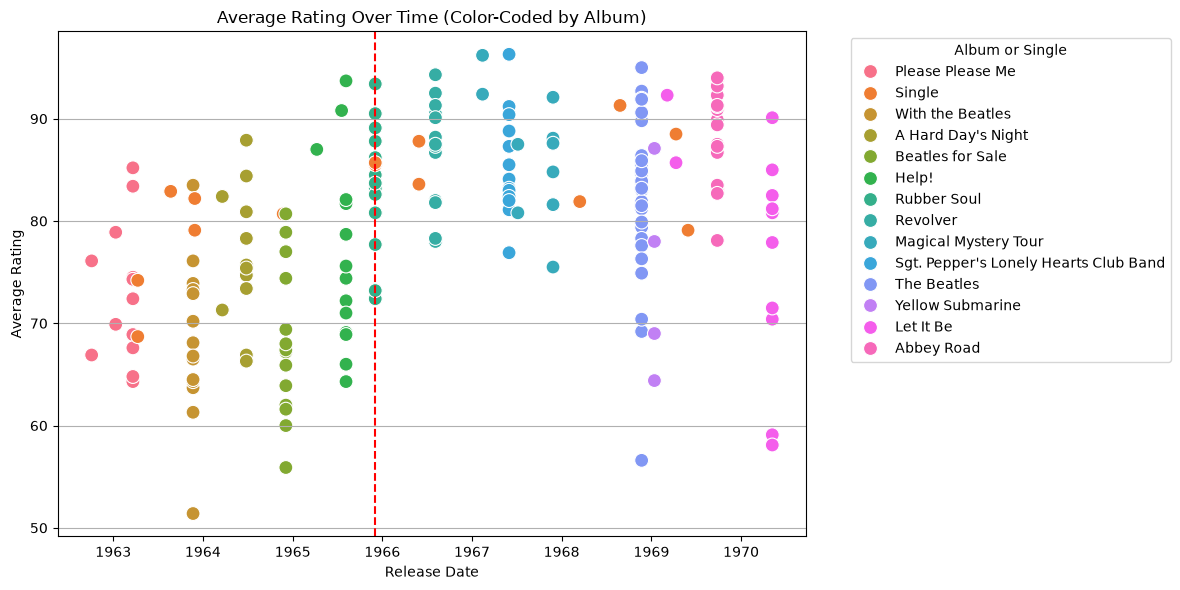

PRE-RUBBER SOUL
Songs: 79
Mean: 72.76
Median: 72.90
Below 70: 40.5%
Above 90: 2.5%

POST-RUBBER SOUL
Songs: 127
Mean: 83.91
Median: 84.10
Below 70: 4.7%
Above 90: 22.0%


In [18]:
# Scatter plot with date on x-axis, avg_rating on y-axis, color coded by album. Add vertical line at Rubber Soul date so split is visually obvious

# Sort dataframe by date
df = df.sort_values(by='Date')

# Plot avg_rating over time, color coded by album
plt.figure(figsize=(12,6)) # Specifying so it's not too small
sns.scatterplot(data=df, x='Date', y='avg_rating', hue='Album', s=100)

# Add/modify labels and title
plt.xlabel("Release Date")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time (Color-Coded by Album)")
plt.legend(title='Album or Single', bbox_to_anchor=(1.05,1), loc='upper left')
plt.axvline(x=rubber_soul_date, color='red', linestyle='--', label='Rubber Soul (1965)')
plt.grid(axis='y')
plt.tight_layout() 
plt.show()

# Summary statistics
print("PRE-RUBBER SOUL")
print(f"Songs: {len(pre_ratings)}")
print(f"Mean: {pre_ratings.mean():.2f}")
print(f"Median: {pre_ratings.median():.2f}")
print(f"Below 70: {(pre_ratings < 70).mean() * 100:.1f}%")
print(f"Above 90: {(pre_ratings > 90).mean() * 100:.1f}%")

print("\nPOST-RUBBER SOUL")
print(f"Songs: {len(post_ratings)}")
print(f"Mean: {post_ratings.mean():.2f}")
print(f"Median: {post_ratings.median():.2f}")
print(f"Below 70: {(post_ratings < 70).mean() * 100:.1f}%")
print(f"Above 90: {(post_ratings > 90).mean() * 100:.1f}%")

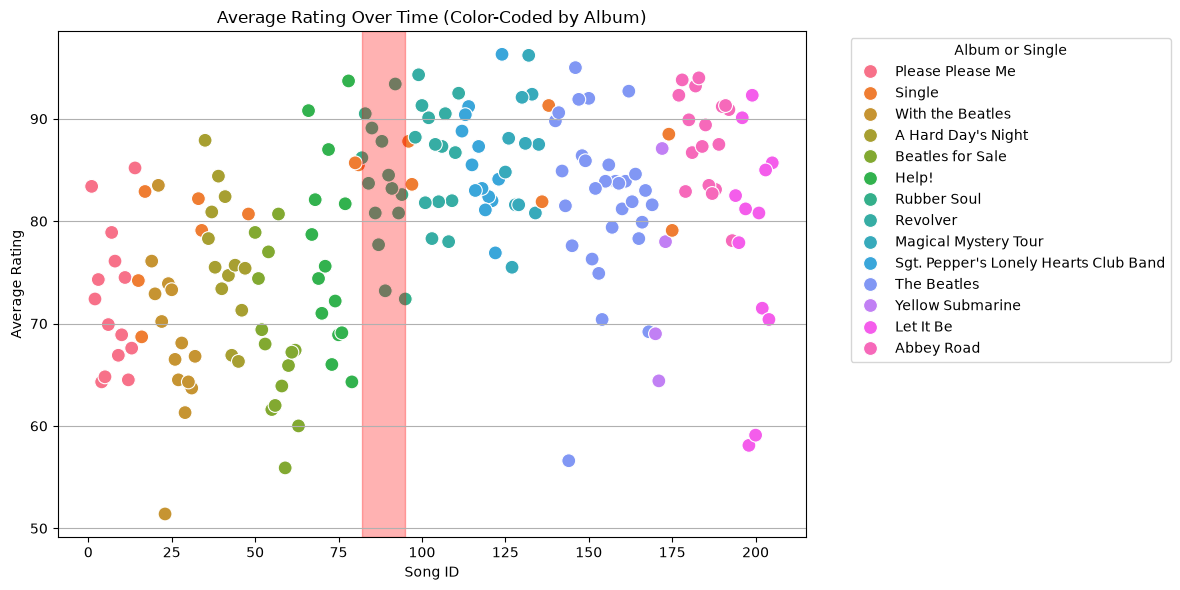

In [6]:
# Same plot but using id instead of date (so you can see the difference between positions as well)
# Plot avg_rating over time, color coded by album
plt.figure(figsize=(12,6)) # Specifying so it's not too small
sns.scatterplot(data=df, x='id', y='avg_rating', hue='Album', s=100)

# Add/modify labels and title
plt.xlabel("Song ID")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time (Color-Coded by Album)")
plt.legend(title='Album or Single', bbox_to_anchor=(1.05,1), loc='upper left')
plt.axvspan(82, 95, color="red", alpha=0.3, label='Rubber Soul IDs (1965)')
plt.grid(axis='y')
plt.tight_layout() 
plt.show()

## Observations and Conclusions
From these two charts, it's evident there exists a shift post-*Rubber Soul*. A few observations:
- Songs do not rate as lowly in the post-*Rubber Soul* dataset as the pre-*Rubber Soul* dataset, with fewer songs getting an average rating below 70. (4.7% post-*Rubber Soul* vs. 40.5% pre-*Rubber Soul*)
- Songs also rate much higher in the post-*Rubber Soul* dataset. (22.0% of songs reaching above 90% for post-*Rubber Soul* data vs. only 2.5% in pre-*Rubber Soul* data)
- Some later albums also appear to have more tightly clustered ratings than others. *Revolver*, *Magical Mystery Tour*, and *Abbey Road*, for example, show relatively consistent reception across their tracks, while *The White Album*, *Yellow Submarine*, and *Let It Be* display greater variation. This may reflect differences in the cohesion, experimentation, or production of these albums, though data alone cannot establish the cause. 

Overall, I'm fairly surprised by how abrupt the shift seems. Rather than showing a gradual improvement across the early-to-mid 60's, the ratings appear to move substantially upward around *Rubber Soul*, and remain elevated afterward. 

The data appears to show a substantial shift in ratings around *Rubber Soul*, though its potential causes and subsequent statistical tests will shed more light on its significance and context.

# Question 2: Song Duration
## Explanation and Context
Did song duration and variability change after *Rubber Soul*, and what might that suggest about the band's creative direction?

While musical experimentation is not something that is easy to quantify, looking at the spread of runtimes of Beatles songs would help in seeing an aspect of their music that changed over time. How did their average song length change over time? Did ceasing to tour give them greater freedom to make songs that they couldn't reasonably play live? Can you see any divergence or trend in song length over time?

## Analysis and Chart Code

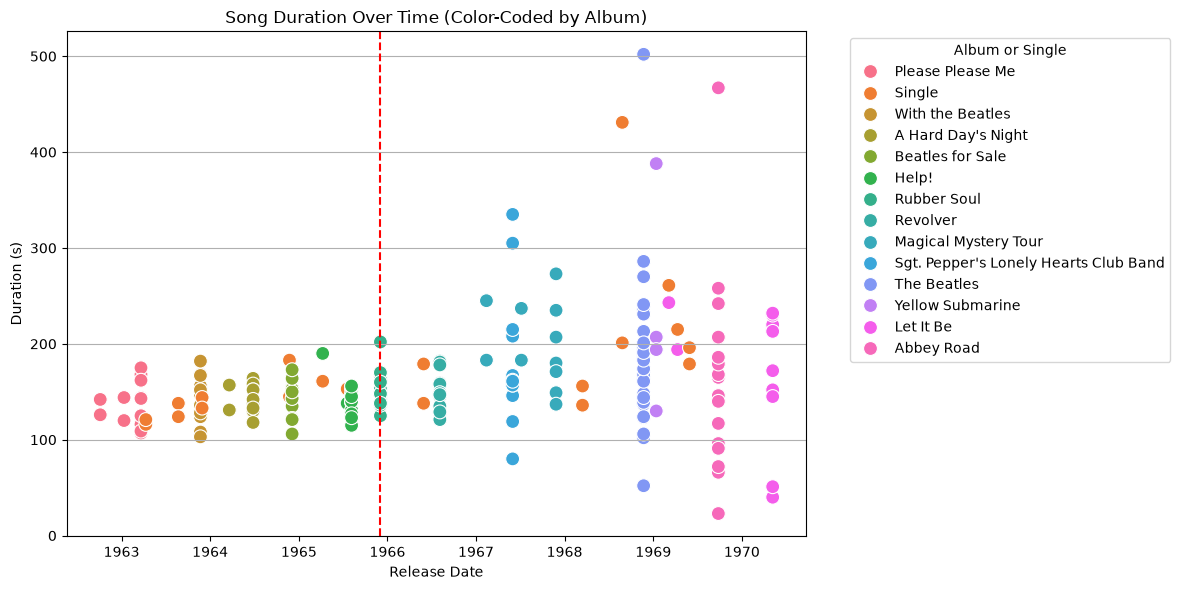

In [7]:
# Scatter plot with date on x-axis, duration on y-axis, color coded by album. Add vertical line at Rubber Soul date so split is visually obvious

# Sort dataframe by date
df = df.sort_values(by='Date')

# Plot duration over time, color coded by album
plt.figure(figsize=(12,6)) # Specifying so it's not too small
sns.scatterplot(data=df, x='Date', y='Duration', hue='Album', s=100)

# Add/modify labels and title
plt.xlabel("Release Date")
plt.ylabel("Duration (s)")
plt.title("Song Duration Over Time (Color-Coded by Album)")
plt.legend(title='Album or Single', bbox_to_anchor=(1.05,1), loc='upper left')
plt.axvline(x=rubber_soul_date, color='red', linestyle='--', label='Rubber Soul (1965)')
plt.grid(axis='y')
plt.tight_layout() 
plt.show()

In [20]:
# Calculate and print the album-by-album average duration and standard-deviation
duration_stats = df.groupby('Album')['Duration'].agg(['count', 'mean', 'std', 'min', 'max']).reindex(album_order)
duration_stats.columns = ['Number of Songs', 'Mean Duration (s)', 'Std Dev (s)', 'Shortest Duration', 'Longest Duration']
print(duration_stats)

# Longest and shortest songs
print(df.nlargest(3, 'Duration')[['Title', 'Album', 'Duration']])
print(df.nsmallest(3, 'Duration')[['Title', 'Album', 'Duration']])

                                       Number of Songs  Mean Duration (s)  \
Album                                                                       
Single                                              22                173   
Please Please Me                                    14                139   
With the Beatles                                    14                141   
A Hard Day's Night                                  13                142   
Beatles for Sale                                    14                143   
Help!                                               14                142   
Rubber Soul                                         14                152   
Revolver                                            14                149   
Sgt. Pepper's Lonely Hearts Club Band               13                183   
Magical Mystery Tour                                11                200   
The Beatles                                         30                185   

## Observations and Conclusions
The chart highlights a substantial increase in variance post-*Rubber Soul*, though the effect seems a bit delayed. Some more observations:
- Spread increases greatly. Not only towards longer and longer songs, but also shorter songs. Pre-*Rubber Soul*, every song was between 100 and 200 seconds (1m40-3m20). Afterward, songs increasingly appear outside this range, including several shorter than 60 seconds, and several longer than 360 seconds (and many all in between).
- Again, the effect is a bit delayed. While the rating shift seemed fairly instantaneous, the shift took another album past *Rubber Soul* to fully materialize. Perhaps this is due to record limitations during the time period, or this really is a variable The Beatles did not change up until after Revolver.
- The tables further complement the same ideas that the graph gave. Mean duration was steady from their first album to Revolver, then ballooned afterwards (though slowly seemed to fall back down to ~3m average). Standard deviation similarly shot up, and never really came back down, even for *Let It Be*.

I believe song duration to be an important marker that can tell us more about what The Beatles were doing with their music. Regardless of what may have contributed to the changes, whether they be commercial constraints, the end of touring, or pure creative restlessness, it's clear that the distribution of song durations changes substantially around the *Sgt. Pepper's* period. While this is not a post-*Rubber Soul* shift, it is still an event that highlights the changes in the music that they wanted to make. 

This complicates the *Rubber Soul* narrative slightly. The quality shift in ratings appears earlier than the duration shift, suggesting that the two changes, while related, were not simultaneous, and that different dimensions of The Beatles' development changed at different times. 

# Question 3: Songwriter Contributions
## Explanation and Context
How did primary songwriting credits shift across the Beatles' career, and does the post-*Rubber Soul* era look compositionally different?

One of the most interesting facts about The Beatles is that every member has composed at least one song in their catalog, with all four going on to have significant solo careers after the band's breakup. While some (i.e. Lennon and McCartney) obviously dominated when it came to creating songs for the band, how did the actual composition of songwriters change over time? Is there a real difference pre and post-Rubber Soul? What might this suggest, if so?

## Analysis and Chart Code

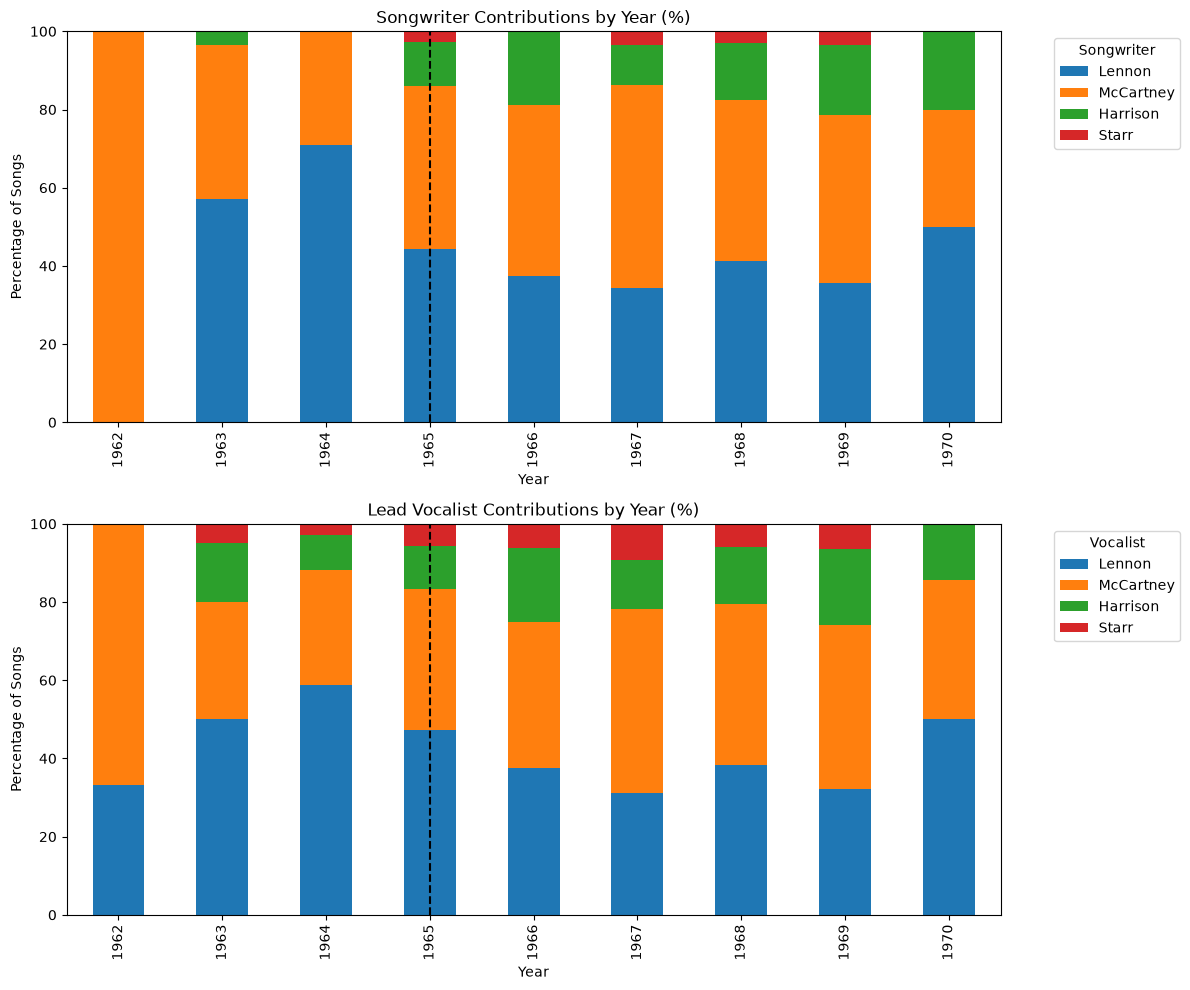

In [9]:
# Stacked area chart showing proportion of songs credited to either Lennon, McCartney, Harrison, or Starr by year
beatles = ['Lennon', 'McCartney', 'Harrison', 'Starr']

for beatle in beatles:
    df[beatle + '_writer'] = df['Songwriter'].apply(lambda x: 1 if beatle in str(x) else 0)
for beatle in beatles:
    df[beatle + '_vocalist'] = df['LeadVocal'].apply(lambda x: 1 if beatle in str(x) else 0)

writer_cols = [b + '_writer' for b in beatles]
vocal_cols = [b + '_vocalist' for b in beatles]

# Extract year from Date
df['Year'] = df['Date'].dt.year

# Group by year and convert to percentage
songwriter_contributions = df.groupby('Year')[writer_cols].sum()
songwriter_contributions = songwriter_contributions.div(songwriter_contributions.sum(axis=1), axis=0) * 100

vocalist_contributions = df.groupby('Year')[vocal_cols].sum()
vocalist_contributions = vocalist_contributions.div(vocalist_contributions.sum(axis=1), axis=0) * 100

# Rename columns for cleaner legend
songwriter_contributions.columns = beatles
vocalist_contributions.columns = beatles

# Plot both graphs out
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Add/modify labels and title, add vertical line
songwriter_contributions.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_title('Songwriter Contributions by Year (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Percentage of Songs')
ax1.legend(title='Songwriter', bbox_to_anchor=(1.05, 1))
ax1.axvline(x=list(songwriter_contributions.index).index(1965), color='black', linestyle='--', label='Rubber Soul (1965)')

vocalist_contributions.plot(kind='bar', stacked=True, ax=ax2)
ax2.set_title('Lead Vocalist Contributions by Year (%)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Percentage of Songs')
ax2.legend(title='Vocalist', bbox_to_anchor=(1.05, 1))
ax2.axvline(x=list(vocalist_contributions.index).index(1965), color='black', linestyle='--', label='Rubber Soul (1965)')

plt.tight_layout()
plt.show()

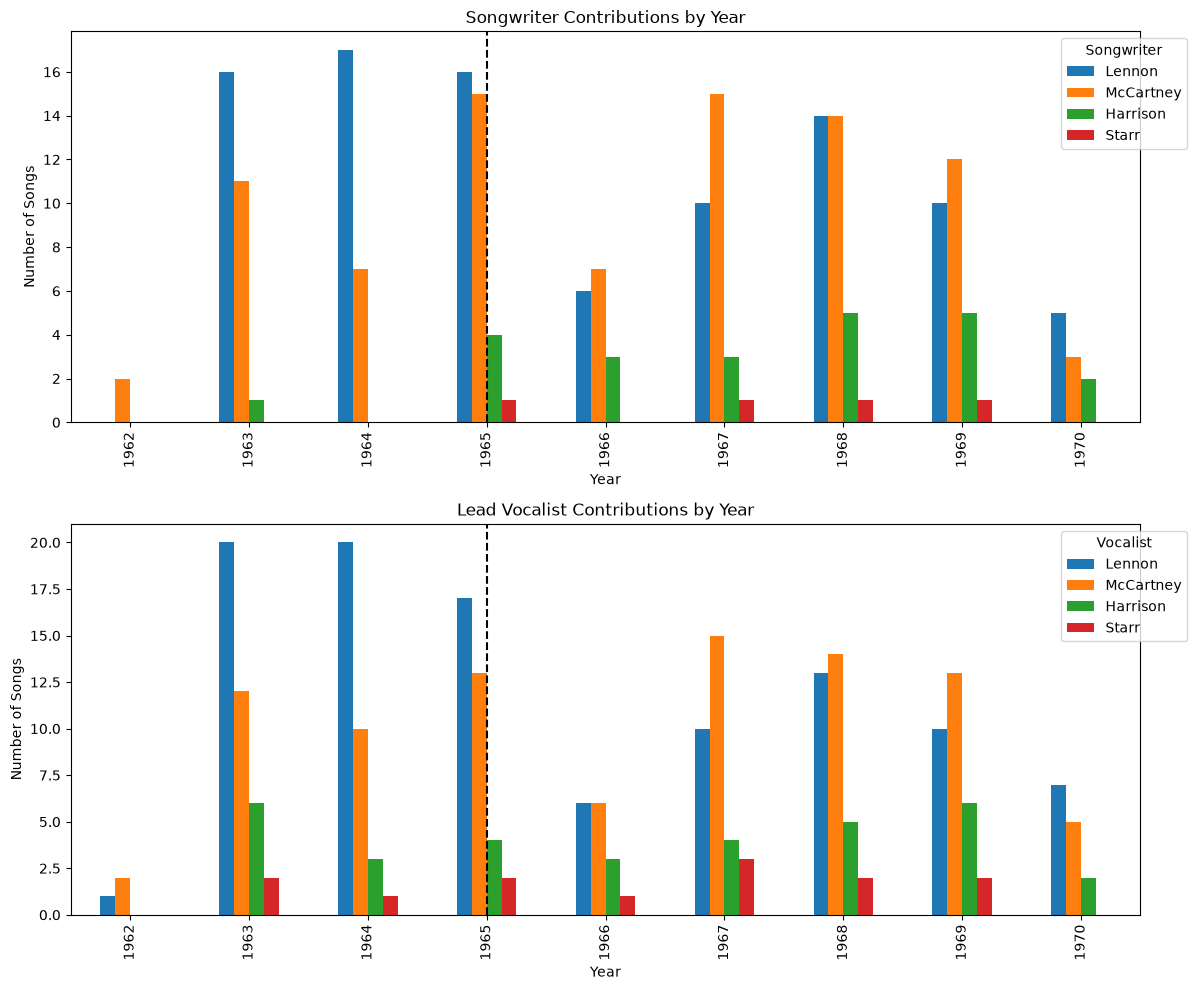

In [10]:
# Grouped bar chart showing number of songs credited to either Lennon, McCartney, Harrison, or Starr by year
# Group by year and keep as raw number
songwriter_contributions = df.groupby('Year')[writer_cols].sum()
songwriter_contributions.columns = beatles

vocalist_contributions = df.groupby('Year')[vocal_cols].sum()
vocalist_contributions.columns = beatles

# Plot both graphs out
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Add/modify labels and title, add vertical line
songwriter_contributions.plot(kind='bar', stacked=False, ax=ax1)
ax1.set_title('Songwriter Contributions by Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Songs')
ax1.legend(title='Songwriter', bbox_to_anchor=(1.05, 1))
ax1.axvline(x=list(songwriter_contributions.index).index(1965), color='black', linestyle='--', label='Rubber Soul (1965)')

vocalist_contributions.plot(kind='bar', stacked=False, ax=ax2)
ax2.set_title('Lead Vocalist Contributions by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Songs')
ax2.legend(title='Vocalist', bbox_to_anchor=(1.05, 1))
ax2.axvline(x=list(vocalist_contributions.index).index(1965), color='black', linestyle='--', label='Rubber Soul (1965)')

plt.tight_layout()
plt.show()

## Observations and Conclusions
Both charts show some pretty interesting data. 
- There was absolutely a shift for Lennon and McCartney as songwriters and vocalists. Pre-*Rubber Soul*, Lennon absolutely dominated both. Post-*Rubber Soul*, while he still had a very solid output, McCartney ended up outpacing him, or at least matching him in every year since until 1970. 
- Harrison also had a steady increase post-*Rubber Soul*. While he performed fairly often throughout the band's career, his actual songwriting wasn't present (except in one song) pre-*Rubber Soul*. Afterwards, however, he stays consistent in writing and performing multiple songs per year for The Beatles.
- Ringo's contributions are worth noting because of how minimal they are. He rarely writes or leads vocally, but was still outputting fairly consistently throughout the band's run. It's also worth noting that all 4 of his writing contributions were post-*Rubber Soul*

Like the rating graphs we saw, I'm surprised by how sudden the shift occurred. In *Rubber Soul*, McCartney started writing and performing much more, which wouldn't really go down until *Let It Be*, while Lennon' output declined relative to McCartney's post-*Rubber Soul*. This creates a very interesting dynamic, where the directional shift of each album becomes almost audible. You can hear whose influence was dominant in a given period.

I'm also surprised about Harrison's output, specifically that it was pretty steady throughout most of the post-*Rubber Soul* era. My initial thought was that you could see a gradual rise in the number of his songs, which does happen, but not as dramatically as I would have expected. In the post-*Rubber Soul* era, he pens 3-5 songs per year (excluding *Let It Be*), and that's pretty consistent. His vocal contributions do show more of an upward trend, however. 

The post-*Rubber Soul* period therefore differs compositionally from the band's early period. McCartney's share of songwriting becomes increasingly prominent, Harrison establishes a recurring songwriting presence, and Starr begins contributing original material. These changes coincide with broader changes in ratings and song durations observed elsewhere in this analysis, suggesting that the post-*Rubber Soul* period represented a meaningful shift both in how The Beatles' music was being created, as well as received.

# Main Question: The Rubber Soul Question
## Explanation and Context
Is the perceived quality shift after *Rubber Soul* statistically significant, or just a matter of perception?

I would certainly agree that The Beatles' output post-1965 was much changed, but that's only speaking from my personal tastes and experiences. Does this hold up statistically? With all the data we now have, can the data support the claim that there was a real shift post-*Rubber Soul*?

## Analysis and Chart Code

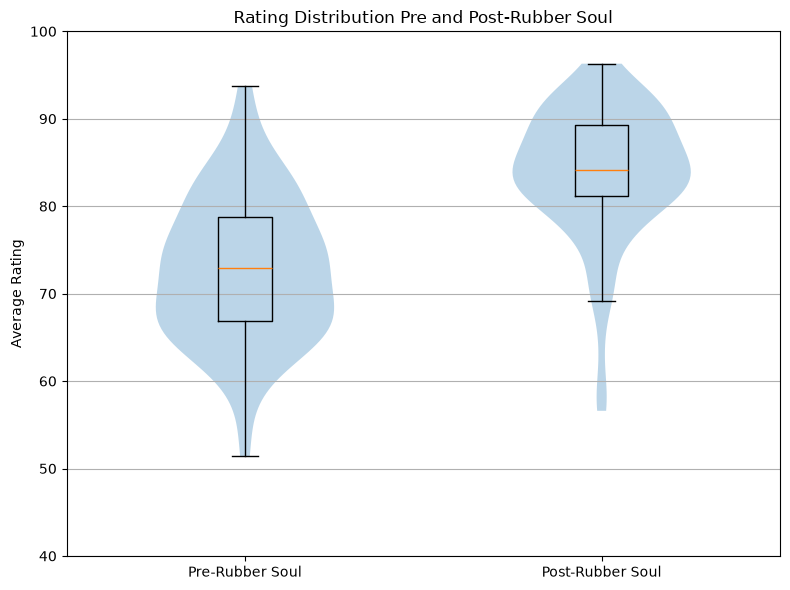

Pre-Rubber Soul:
Median: 73
Q1: 67
Q3: 79

Post-Rubber Soul:
Median: 84
Q1: 81
Q3: 89


In [11]:
# Side by side box + violin plot showing rating distribution for pre and post Rubber Soul songs
# Setting up pre and post ratings
pre_ratings = pre_rs['avg_rating'].dropna().values
post_ratings = post_rs['avg_rating'].dropna().values

# Plot the boxplot out
fig, ax = plt.subplots(figsize=(8, 6))

# Violin
ax.violinplot(
    [pre_ratings, post_ratings],
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Box plot on top
ax.boxplot(
    [pre_ratings, post_ratings],
    showfliers=False
)

# Setting labels/title
ax.set_xticks([1, 2])
ax.set_xticklabels(['Pre-Rubber Soul', 'Post-Rubber Soul'])
ax.set_ylabel("Average Rating")
ax.set_title("Rating Distribution Pre and Post-Rubber Soul")
ax.set_ylim(40, 100)
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# Print some extra textual information about the plot
print("Pre-Rubber Soul:")
print(f"Median: {pre_rs['avg_rating'].median():.0f}")
print(f"Q1: {pre_rs['avg_rating'].quantile(0.25):.0f}")
print(f"Q3: {pre_rs['avg_rating'].quantile(0.75):.0f}")

print("\nPost-Rubber Soul:")
print(f"Median: {post_rs['avg_rating'].median():.0f}")
print(f"Q1: {post_rs['avg_rating'].quantile(0.25):.0f}")
print(f"Q3: {post_rs['avg_rating'].quantile(0.75):.0f}")

In [21]:
# T-test to evaluate whether mean song ratings differ before and after Rubber Soul
# Extract the avg_rating values for both groups
pre_ratings = pre_rs['avg_rating'].dropna()
post_ratings = post_rs['avg_rating'].dropna()

# Perform the independent t-test
t_stat, p_value = stats.ttest_ind(pre_ratings, post_ratings, equal_var=False)

# Output the results
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")

T-statistic: -9.60, P-value: 0.0000


## Observations and Conclusions
### The chart
The violin plot expands on the trend observed in the average ratings over time chart by showing how the entire distribution of song ratings changed before and after *Rubber Soul*. 
- The post-*Rubber Soul* distribution is clearly shifted upward. Both the center and upper end of the ratings are substantially higher, while the pre-*Rubber Soul* tracks occupy a considerably lower range overall.
- The distribution also changes in shape. In the pre-*Rubber Soul* period, ratings are relatively evenly distributed around the median, whereas the post-*Rubber Soul* distribution is more concentrated towards the higher ratings. In particular, the upper portion (Q1) of the post-*Rubber Soul* distribution extends considerably farther htan its lower portion. This suggests the improvement was not simply the result of a few exceptionally highly rated songs, but rather a larger proportion of the songs receiving high ratings.
- At the same time, the post-Rubber Soul period contains several low-rated outliers. This may reflect a greater willingness to include unconventional, experimental, or otherwise less conventionally polished material along their strongest work (i.e. *Revolution 9*, *Wild Honey Pie*, *Flying*). In other words, the increase in average quality did not necessarily mean that every individual song became better. 

Overall, this plot provides one of the clearest visual representations of the apparent shift following *Rubber Soul*. The difference between the two distributions is substantial: the post-*Rubber Soul* songs are generally rated higher, while the period also shows a wider range of material at the lower end. The t-test will provide the inferential evidence needed to determine whether the difference between the two periods is statistically significant. 

### The t-test
Welch's independent-samples t-test evaluates whether mean song ratings differ before and after Rubber Soul. Our null hypothesis is that mean song rating is the same before and after *Rubber Soul*, and our alternative hypothesis is that rating differs between the two periods. 

The result indicated a T-statistic of -9.60, and a P-value of 0.0000. The negative 

# Conclusion